In [52]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\Sajib
[nltk_data]     Saha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Sajib
[nltk_data]     Saha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Sajib
[nltk_data]     Saha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Sajib
[nltk_data]     Saha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [53]:
df = pd.read_csv("Twitter_Data.csv")

In [54]:
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [55]:
df.isna().sum()

clean_text    4
category      7
dtype: int64

In [56]:
df.shape

(162980, 2)

In [57]:
df= df.dropna()

In [58]:
import re

# stopwords
stop_w = set(stopwords.words('english'))

# lemmatizer
lemmatizer = WordNetLemmatizer()

def text_preprocessing(phrase): # class e convert kore niben

    # lowercase
    phrase = phrase.lower()

    # contractions
    phrase = re.sub(r"won't", "will not", phrase)
    phrase = re.sub(r"can't", "can not", phrase)

    # general contractions
    phrase = re.sub(r"n't", " not", phrase)
    phrase = re.sub(r"'re", " are", phrase)
    phrase = re.sub(r"'s", " is", phrase)
    phrase = re.sub(r"'d", " would", phrase)
    phrase = re.sub(r"'ll", " will", phrase)
    phrase = re.sub(r"'ve", " have", phrase)
    phrase = re.sub(r"'m", " am", phrase)

    # custom replacement
    phrase = re.sub(r"luv", "love", phrase)

    # remove emoji, punctuation, digits
    phrase = re.sub(r"[^a-zA-Z\s]", " ", phrase)

    # remove extra spaces
    phrase = re.sub(r"\s+", " ", phrase).strip()

    # tokenize
    words = phrase.split()

    # stopword removal + lemmatization
    words = [
        lemmatizer.lemmatize(word.lower())
        for word in words
        if word not in stop_w
    ]

    return " ".join(words)

# apply
df["text"] = df["clean_text"].apply(text_preprocessing)

In [59]:
df.head()

,clean_text,category,text
0,when modi promised “minimum government maximum...,-1.0,modi promised minimum government maximum gover...
1,talk all the nonsense and continue all the dra...,0.0,talk nonsense continue drama vote modi
2,what did just say vote for modi welcome bjp t...,1.0,say vote modi welcome bjp told rahul main camp...
3,asking his supporters prefix chowkidar their n...,1.0,asking supporter prefix chowkidar name modi gr...
4,answer who among these the most powerful world...,1.0,answer among powerful world leader today trump...


In [60]:
x = df["text"]
y = df[["category"]]

In [61]:
split_range= .80
len_x = len(x)
split_num = int(split_range*len_x)
train_text = x[:split_num]
train_label = y[:split_num]

test_text = x[split_num:]
test_label= y[split_num:]

In [62]:
test_text

130376    pradhan mantri mudra yojana crore people got m...
130377                                 modi everywhere like
130378    modi gatbandhan cbi medium calling name genuin...
130379    attacking congress modi said grand old party s...
130380    ill chowkidaar power modi realized chowkidaar ...
                                ...                        
162975    crore paid neerav modi recovered congress lead...
162976    dear rss terrorist payal gawar modi killing pl...
162977                         cover interaction forum left
162978    big project came india modi dream project happ...
162979    ever listen like gurukul discipline maintained...
Name: text, Length: 32594, dtype: object

In [63]:
test_label

,category
130376,-1.0
130377,0.0
130378,1.0
130379,1.0
130380,-1.0
...,...
162975,-1.0
162976,-1.0
162977,0.0
162978,0.0


In [64]:
from gensim.models import Word2Vec, KeyedVectors

embedding_size= 256
model = Word2Vec(train_label, vector_size= embedding_size, window=7, min_count=1, workers=4)

In [65]:
import numpy as np

def getVectors(dataset):
    vectors = []

    for dataItem in dataset:
        singleDataItemEmbedding = np.zeros(embedding_size)
        wordCount = 0

        for word in dataItem:
            if word in model.wv.key_to_index:
                singleDataItemEmbedding += model.wv[word]
                wordCount += 1

        if wordCount > 0:
            singleDataItemEmbedding /= wordCount

        vectors.append(singleDataItemEmbedding)

    return np.array(vectors)


trainReviewVectors = getVectors(train_text)
testReviewVectors = getVectors(test_text)

In [66]:
trainReviewVectors

array([[-1.43037063e-03, -8.95771529e-05, -4.93436974e-04, ...,
        -6.73472033e-04, -1.70011504e-03,  8.51441470e-04],
       [-1.24293689e-03, -7.98699577e-04, -9.87401058e-04, ...,
         2.00807404e-04, -1.74480659e-03,  1.67829675e-03],
       [-6.57245294e-04, -1.25642544e-03, -1.02847628e-03, ...,
        -2.54091889e-04, -1.29358871e-03,  1.17232038e-03],
       ...,
       [-3.81541881e-04, -1.33846053e-03, -9.61157863e-04, ...,
        -8.45818012e-04, -8.18215832e-04,  7.01782868e-04],
       [-6.59838754e-04, -1.08965403e-03, -7.38541149e-04, ...,
        -6.52309565e-04, -1.04290751e-03,  6.22933600e-04],
       [-6.26740572e-05, -8.29525894e-04, -9.21221793e-04, ...,
        -1.39222050e-04, -2.73642798e-04,  8.90825243e-04]],
      shape=(130375, 256))

In [ ]:
# evaluation matrix define 
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
def result(yture, y_pred):
    print(classification_report(yture, y_pred))
    col_name = ["Yes","No"]
    print(sns.heatmap(confusion_matrix(yture, y_pred), annot=True, cmap="Reds"))

c:\Users\Sajib Saha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              precision    recall  f1-score   support

        -1.0       0.28      0.06      0.10      7229
         0.0       0.51      0.48      0.50     11043
         1.0       0.49      0.71      0.58     14322

    accuracy                           0.49     32594
   macro avg       0.43      0.42      0.39     32594
weighted avg       0.45      0.49      0.45     32594

Axes(0.125,0.11;0.62x0.77)


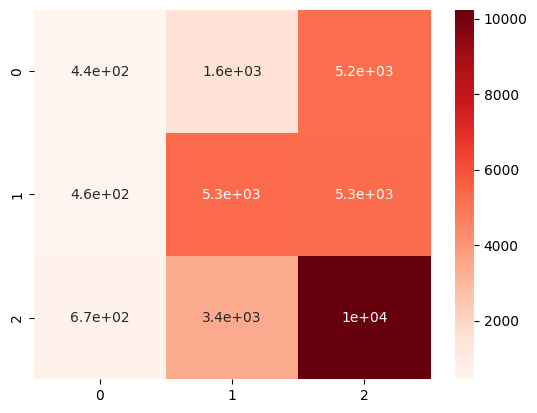

In [69]:
# Scaling values and model building
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier

rnaf=RandomForestClassifier()
rsc= RobustScaler()

train_data = rsc.fit_transform(trainReviewVectors)
test_data= rsc.transform(testReviewVectors)

model = rnaf.fit(train_data,train_label)
pred_data = model.predict(test_data)

result(test_label, pred_data)


In [ ]:
pred = 